# Model Building 

In [327]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report, roc_auc_score, recall_score, precision_score, f1_score, brier_score_loss
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [211]:
df = pd.read_csv('../data/processed/patient_journey.csv')
df.columns.to_list()

['Unnamed: 0',
 'patient_id',
 'inquiry_date',
 'country',
 'age_group',
 'gender',
 'treatment_category',
 'provider_id',
 'lead_source',
 'coordinator_id',
 'budget_band',
 'medical_urgency',
 'intent_score',
 'response_time_hours',
 'engagement_score',
 'consultation_booked',
 'quote_shared',
 'treatment_completed',
 'follow_up_completed',
 'current_stage',
 'drop_off_flag',
 'drop_off_stage',
 'reason_for_drop_off',
 'estimated_case_value_inr',
 'actual_revenue_inr',
 'service_cost_inr',
 'satisfaction_score']

## Treatment Completation Model

In [212]:
drop_cols = [
    
    'Unnamed: 0', 'treatment_completed', 'patient_id', 'inquiry_date',
    # Post-outcome
    'actual_revenue_inr',
    'satisfaction_score',
    'service_cost_inr',
    # future events
    'consultation_booked',
    'quote_shared',
    'follow_up_completed',
    # Directly related to patient dropping/completing journey
    'current_stage',
    'drop_off_flag',
    'drop_off_stage',
    'reason_for_drop_off'
]

x = df.drop(columns=drop_cols)
y = df['treatment_completed']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [213]:
x_train.dtypes

country                         str
age_group                       str
gender                          str
treatment_category              str
provider_id                     str
lead_source                     str
coordinator_id                  str
budget_band                     str
medical_urgency                 str
intent_score                float64
response_time_hours         float64
engagement_score            float64
estimated_case_value_inr      int64
dtype: object

In [214]:
numeric_features = x_train.select_dtypes(include=['int64', 'float64', 'datetime64']).columns.to_list()
categorical_features = x_train.select_dtypes(include=['str', 'object']).columns.to_list()

In [215]:
numeric_pipline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipline, numeric_features),
    ('cat', categorical_pipline, categorical_features)
])

### Logistic Regression

In [216]:
lr_pipline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=10000,
        random_state=149
    ))
])

skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=149)
scores = cross_val_score(lr_pipline, x_train, y_train, cv=skfold, scoring='roc_auc', n_jobs=-1)

print(scores)

[0.76016746 0.7538128  0.76955131 0.82111764 0.72922092]


In [217]:
lr_pipline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['country','age_group','gender',...,'response_time_hours', 'engagement_score','estimated_case_value_inr']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [218]:
y_pred_lr = lr_pipline.predict(x_test)
y_prob_lr = lr_pipline.predict_proba(x_test)[:,1]

In [219]:
ps_lr = precision_score(y_test, y_pred_lr)
rs_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
bs_lr = brier_score_loss(y_test, y_prob_lr)

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.77      0.80      0.79       189
           1       0.64      0.59      0.61       111

    accuracy                           0.72       300
   macro avg       0.70      0.69      0.70       300
weighted avg       0.72      0.72      0.72       300



In [220]:
ra_lr = roc_auc_score(y_test, y_prob_lr)
ra_lr

0.7910767910767911

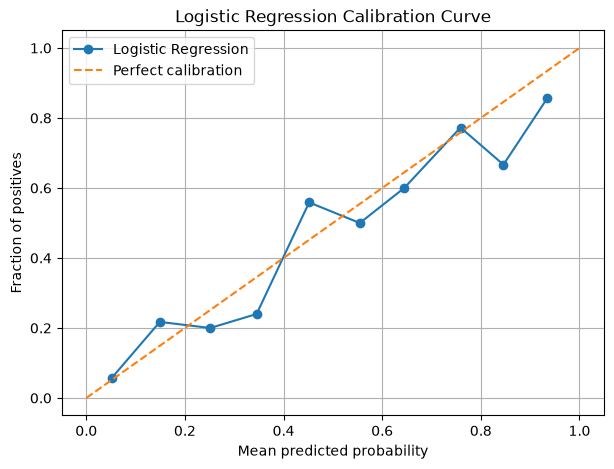

In [221]:
prob_true_lr, prob_pred_lr = calibration_curve(
    y_test,
    y_prob_lr,
    n_bins=10
)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred_lr, prob_true_lr, marker="o", label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Logistic Regression Calibration Curve")

plt.grid()
plt.legend()
plt.show()

### KNN

In [222]:
knn_pipline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1,p=1))
])

skfold_knn = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)

roc_score_knn = cross_val_score(knn_pipline, x_train, y_train, cv=skfold, scoring='roc_auc', n_jobs=-1)
roc_score_knn

array([0.70241477, 0.73717853, 0.6929459 , 0.74157303, 0.68323536])

In [223]:
knn_pipline.fit(x_train, y_train)
y_pred_knn = knn_pipline.predict(x_test)
y_prob_knn = knn_pipline.predict_proba(x_test)[:,1]

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.77      0.80      0.79       189
           1       0.64      0.59      0.62       111

    accuracy                           0.73       300
   macro avg       0.71      0.70      0.70       300
weighted avg       0.72      0.73      0.72       300



In [224]:
ps_knn = precision_score(y_test, y_pred_knn)
rs_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
bs_knn = brier_score_loss(y_test, y_prob_knn)

In [225]:
ra_knn = roc_auc_score(y_test, y_prob_knn)
ra_knn

0.766909766909767

### Decision Tree

In [226]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=149,
        max_depth=5,
    ))
])

skfold_dt = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)

roc_score_dt = cross_val_score(dt_pipeline, x_train, y_train, cv=skfold_dt, scoring='roc_auc', n_jobs=-1)
roc_score_dt

array([0.74114085, 0.7719049 , 0.80936082, 0.81200238, 0.80444974])

In [227]:
dt_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['country','age_group','gender',...,'response_time_hours', 'engagement_score','estimated_case_value_inr']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [228]:
y_pred_dt = dt_pipeline.predict(x_test)
y_prob_dt = dt_pipeline.predict_proba(x_test)[:,1]

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.84      0.83      0.83       189
           1       0.71      0.73      0.72       111

    accuracy                           0.79       300
   macro avg       0.77      0.78      0.78       300
weighted avg       0.79      0.79      0.79       300



In [229]:
ps_dt = precision_score(y_test, y_pred_dt)
rs_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
bs_dt = brier_score_loss(y_test, y_prob_dt)

In [230]:
ra_dt = roc_auc_score(y_test, y_prob_dt)
ra_dt

0.8399113399113399

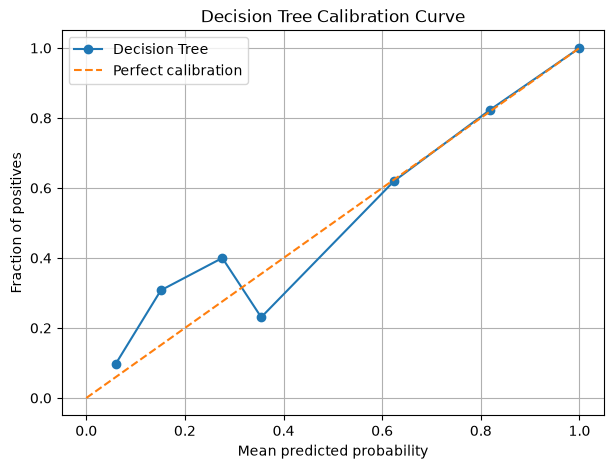

In [231]:
prob_true_dt, prob_pred_dt = calibration_curve(
    y_test,
    y_prob_dt,
    n_bins=10
)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred_dt, prob_true_dt, marker="o", label="Decision Tree")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Decision Tree Calibration Curve")

plt.grid()
plt.legend()
plt.show()

### Random Forest

In [232]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=149,
        n_jobs=-1
    ))
])

skfold_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=18)

roc_score_rf = cross_val_score(rf_pipeline, x_train, y_train, cv=skfold_rf, scoring='roc_auc', n_jobs=-1)
roc_score_rf

array([0.84303977, 0.81283642, 0.8439244 , 0.79079545, 0.75154401])

In [233]:
rf_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['country','age_group','gender',...,'response_time_hours', 'engagement_score','estimated_case_value_inr']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [234]:
y_pred_rf = rf_pipeline.predict(x_test)
y_prob_rf = rf_pipeline.predict_proba(x_test)[:,1]

In [235]:
ps_rf = precision_score(y_test, y_pred_rf)
rs_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
bs_rf = brier_score_loss(y_test, y_prob_rf)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.81      0.92      0.86       189
           1       0.82      0.62      0.71       111

    accuracy                           0.81       300
   macro avg       0.81      0.77      0.78       300
weighted avg       0.81      0.81      0.80       300



In [236]:
ra_rf = roc_auc_score(y_test, y_pred_rf)
ra_rf

0.7711282711282711

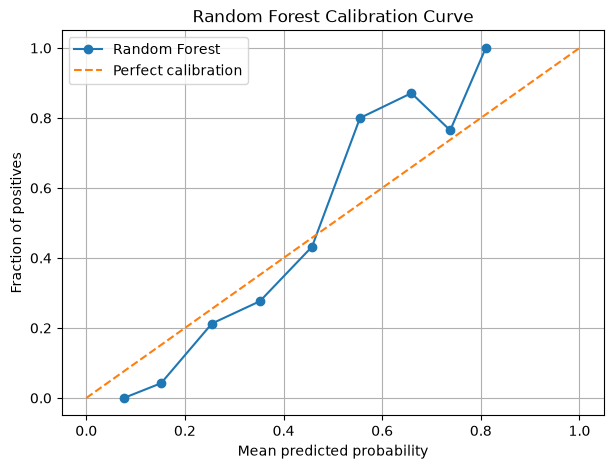

In [237]:
prob_true_rf, prob_pred_rf = calibration_curve(
    y_test,
    y_prob_rf,
    n_bins=10
)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred_rf, prob_true_rf, marker="o", label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Random Forest Calibration Curve")

plt.grid()
plt.legend()
plt.show()

### Score Table

In [238]:
models = ['LR', 'KNN', 'DT', 'RF']
score_table = pd.DataFrame({
    'ROC-AUC':[ra_lr, ra_knn, ra_dt, ra_rf],
    'Precision':[ps_lr, ps_knn, ps_dt, ps_rf],
    'Recall':[rs_lr, rs_knn, rs_dt, rs_rf],
    'Brier':[bs_lr, bs_knn, bs_dt, bs_rf],
}, index=models
)

In [239]:
score_table

,ROC-AUC,Precision,Recall,Brier
LR,0.791077,0.637255,0.585586,0.178702
KNN,0.766910,0.640777,0.594595,0.185254
DT,0.839911,0.710526,0.729730,0.154523
RF,0.771128,0.821429,0.621622,0.154034


The Decision Tree provides the strongest overall predictive performance, achieving the highest ROC-AUC (0.840) and recall (0.730), while Random Forest achieves the highest precision (0.821) and marginally lower Brier score (0.154).

### Parameter Tuning of Decision Tree

In [240]:
dt_pipeline_tune = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(random_state=18,))
])

skfold_dt = StratifiedKFold(n_splits=5, shuffle=True, random_state=149)

param_grid = {
    'model__criterion': ['gini', 'entropy', 'log_loss'],
    'model__splitter': ['best', 'random'],
    'model__max_depth': [None, 3, 5, 7, 10, 15],
    'model__min_samples_split': [2, 5, 10, 15, 20],
    'model__min_samples_leaf': [1, 2, 4, 8, 10],
    'model__max_features': [None, 'sqrt', 'log2']
}

gs_dt = GridSearchCV(dt_pipeline_tune, param_grid, cv=skfold_dt, scoring='roc_auc', n_jobs=-1, verbose=1)
gs_dt.fit(x_train, y_train)

Fitting 5 folds for each of 2700 candidates, totalling 13500 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=18))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['gini', 'entropy', ...], 'model__max_depth': [None, 3, ...], 'model__max_features': [None, 'sqrt', ...], 'model__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` par

In [241]:
gs_dt.best_params_

{'model__criterion': 'entropy',
 'model__max_depth': 5,
 'model__max_features': None,
 'model__min_samples_leaf': 4,
 'model__min_samples_split': 15,
 'model__splitter': 'best'}

In [242]:
gs_dt.best_score_

np.float64(0.8003350282518815)

In [243]:
y_pred_dt_tune = gs_dt.predict(x_test)
y_prob_dt_tune = gs_dt.predict_proba(x_test)[:,1]

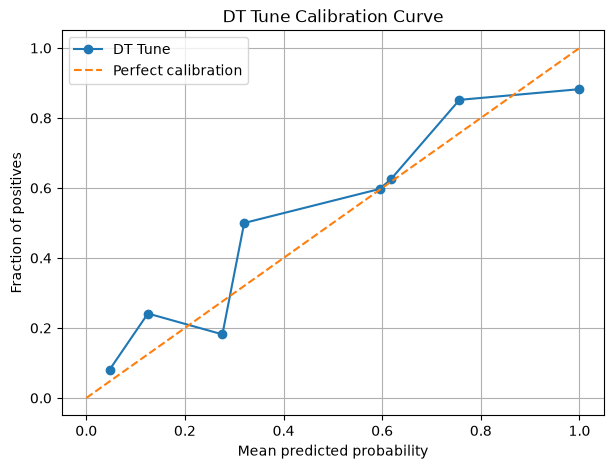

In [244]:
prob_true_dt_tune, prob_pred_dt_tune = calibration_curve(
    y_test,
    y_prob_dt_tune,
    n_bins=10
)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred_dt_tune, prob_true_dt_tune, marker="o", label="DT Tune")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("DT Tune Calibration Curve")

plt.grid()
plt.legend()
plt.show()

In [245]:
score_table

,ROC-AUC,Precision,Recall,Brier
LR,0.791077,0.637255,0.585586,0.178702
KNN,0.766910,0.640777,0.594595,0.185254
DT,0.839911,0.710526,0.729730,0.154523
RF,0.771128,0.821429,0.621622,0.154034


In [246]:
new_row = pd.DataFrame(data={
    'ROC-AUC':roc_auc_score(y_test, y_pred_dt_tune),
    'Precision':precision_score(y_test, y_pred_dt_tune),
    'Recall':recall_score(y_test, y_pred_dt_tune),
    'Brier':brier_score_loss(y_test, y_prob_dt_tune)
}, index=['DT Tune'])

score_table = pd.concat([score_table, new_row])
score_table

,ROC-AUC,Precision,Recall,Brier
LR,0.791077,0.637255,0.585586,0.178702
KNN,0.766910,0.640777,0.594595,0.185254
DT,0.839911,0.710526,0.729730,0.154523
RF,0.771128,0.821429,0.621622,0.154034
DT Tune,0.786858,0.693548,0.774775,0.152222


GridSearchCV produced a model with improved recall and marginally improved Brier score, but lower ROC-AUC and precision on the held-out test set than the baseline Decision Tree.

Hyperparameter tuning did not improve the Decision Tree's overall predictive performance on the held-out test set. The default Decision Tree was therefore retained as the final model.

## Drop off Risk

In [268]:
X = df.drop(columns=drop_cols)
Y = df['drop_off_flag']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=149, stratify=Y)

numeric_features = X_train.select_dtypes(include=['int64', 'float64', 'datetime64']).columns.to_list()
categorical_features = X_train.select_dtypes(include=['str', 'object']).columns.to_list()

numeric_pipline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipline, numeric_features),
    ('cat', categorical_pipline, categorical_features)
])

### Logistic Regression

In [316]:
lr_pipline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=149,
        class_weight='balanced'
    ))
])

skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=149)
scores = cross_val_score(lr_pipline, X_train, Y_train, cv=skfold, scoring='roc_auc', n_jobs=-1)

print(scores)

[0.71282997 0.6546972  0.66284938 0.65673525 0.69536102]


In [317]:
lr_pipline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['country','age_group','gender',...,'response_time_hours', 'engagement_score','estimated_case_value_inr']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [318]:
Y_pred_lr = lr_pipline.predict(X_test)
Y_prob_lr = lr_pipline.predict_proba(X_test)[:, 1]

In [319]:
print(classification_report(Y_test, Y_pred_lr))

              precision    recall  f1-score   support

           0       0.85      0.66      0.74       230
           1       0.36      0.61      0.45        70

    accuracy                           0.65       300
   macro avg       0.60      0.64      0.60       300
weighted avg       0.73      0.65      0.67       300



In [320]:
roc_auc_score(Y_test, Y_prob_lr)

0.6731055900621118

In [321]:
ps_lr = precision_score(Y_test, Y_pred_lr)
rs_lr = recall_score(Y_test, Y_pred_lr)
f1_lr = f1_score(Y_test, Y_pred_lr)
bs_lr = brier_score_loss(Y_test, Y_prob_lr)
ra_lr = roc_auc_score(Y_test, Y_prob_lr)

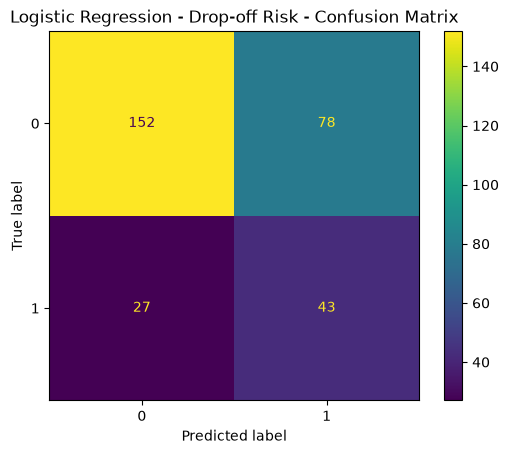

In [328]:
cm = confusion_matrix(Y_test, Y_pred_lr)
ConfusionMatrixDisplay(cm).plot()
plt.title('Logistic Regression - Drop-off Risk - Confusion Matrix')
plt.show()

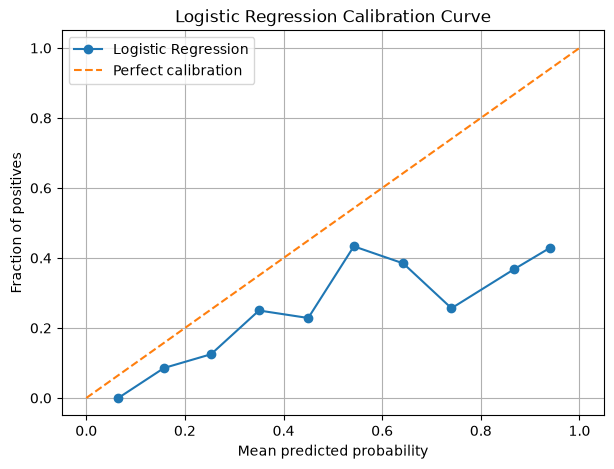

In [330]:
prob_true_lr, prob_pred_lr = calibration_curve(
    Y_test,
    Y_prob_lr,
    n_bins=10
)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred_lr, prob_true_lr, marker="o", label="Logistic Regression")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Logistic Regression Calibration Curve")

plt.grid()
plt.legend()
plt.show()

### Decision Tree

In [304]:
dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=149,
        max_depth=5,
        class_weight='balanced'
    ))
])

skfold_dt = StratifiedKFold(n_splits=5, shuffle=True, random_state=12)

roc_score_dt = cross_val_score(dt_pipeline, X_train, Y_train, cv=skfold_dt, scoring='roc_auc', n_jobs=-1)
roc_score_dt

array([0.65013587, 0.71142275, 0.63349185, 0.66449922, 0.6552795 ])

In [305]:
dt_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['country','age_group','gender',...,'response_time_hours', 'engagement_score','estimated_case_value_inr']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [306]:
Y_pred_dt = dt_pipeline.predict(X_test)
Y_prob_dt = dt_pipeline.predict_proba(X_test)[:,1]

In [307]:
print(classification_report(Y_test, Y_pred_dt))

              precision    recall  f1-score   support

           0       0.86      0.61      0.72       230
           1       0.35      0.67      0.46        70

    accuracy                           0.63       300
   macro avg       0.60      0.64      0.59       300
weighted avg       0.74      0.63      0.66       300



In [308]:
roc_auc_score(Y_test, Y_prob_dt)

0.6250310559006211

In [309]:
ps_dt = precision_score(Y_test, Y_pred_dt)
rs_dt = recall_score(Y_test, Y_pred_dt)
f1_dt = f1_score(Y_test, Y_pred_dt)
bs_dt = brier_score_loss(Y_test, Y_prob_dt)
ra_dt = roc_auc_score(Y_test, Y_prob_dt)

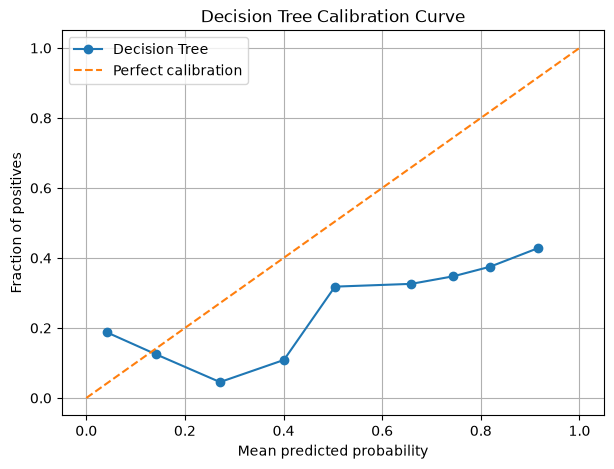

In [332]:
prob_true_dt, prob_pred_dt = calibration_curve(
    Y_test,
    Y_prob_dt,
    n_bins=10
)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred_dt, prob_true_dt, marker="o", label="Decision Tree")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Decision Tree Calibration Curve")

plt.grid()
plt.legend()
plt.show()

### Random Forest

In [310]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=149,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

skfold_rf = StratifiedKFold(n_splits=5, shuffle=True, random_state=18)

roc_score_rf = cross_val_score(rf_pipeline, X_train, Y_train, cv=skfold_rf, scoring='roc_auc', n_jobs=-1)
roc_score_rf

array([0.71773098, 0.71860443, 0.74175078, 0.74471079, 0.73403533])

In [311]:
rf_pipeline.fit(X_train, Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['country','age_group','gender',...,'response_time_hours', 'engagement_score','estimated_case_value_inr']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying

In [312]:
Y_pred_rf = rf_pipeline.predict(X_test)
Y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

In [313]:
print(classification_report(Y_test, Y_pred_rf))

              precision    recall  f1-score   support

           0       0.78      0.79      0.79       230
           1       0.29      0.29      0.29        70

    accuracy                           0.67       300
   macro avg       0.54      0.54      0.54       300
weighted avg       0.67      0.67      0.67       300



In [314]:
roc_auc_score(Y_test, Y_prob_rf)

0.6648136645962732

In [315]:
ps_rf = precision_score(Y_test, Y_pred_rf)
rs_rf = recall_score(Y_test, Y_pred_rf)
f1_rf = f1_score(Y_test, Y_pred_rf)
bs_rf = brier_score_loss(Y_test, Y_prob_rf)
ra_rf = roc_auc_score(Y_test, Y_prob_rf)

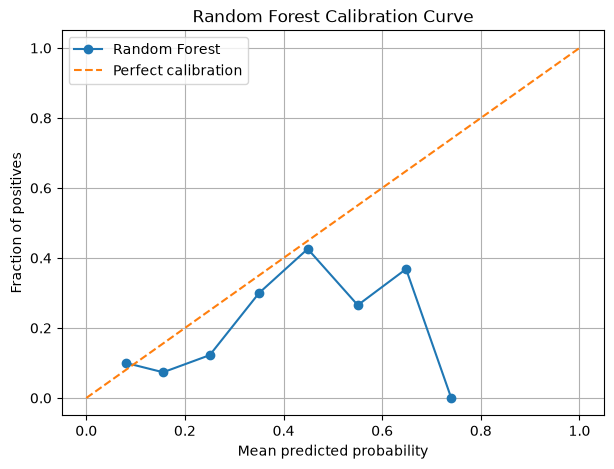

In [334]:
prob_true_rf, prob_pred_rf = calibration_curve(
    Y_test,
    Y_prob_rf,
    n_bins=10
)

plt.figure(figsize=(7, 5))
plt.plot(prob_pred_rf, prob_true_rf, marker="o", label="Random Forest")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Random Forest Calibration Curve")

plt.grid()
plt.legend()
plt.show()

### Score Table

In [322]:
models = ['LR', 'DT', 'RF']
score_table = pd.DataFrame(data={
    'ROC-AUC':[ra_lr, ra_dt, ra_rf],
    'Precision':[ps_lr, ps_dt, ps_rf],
    'Recall':[rs_lr, rs_dt, rs_rf],
    'Brier':[bs_lr, bs_dt, bs_rf],
}, index=models)
score_table

,ROC-AUC,Precision,Recall,Brier
LR,0.673106,0.355372,0.614286,0.232982
DT,0.625031,0.345588,0.671429,0.250690
RF,0.664814,0.289855,0.285714,0.187328
